In [1]:
# ===============================================
# BASIC SETUP: GIT Auth and mounting google drive
# ================================================

from google.colab import drive
import sys

# Standard mount to access the config file initially
drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/src')

from utils.config import initialize_project
initialize_project()

Mounted at /content/drive
Authenticated as: Ande404
Working Directory: /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench


In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

project_root = "/content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench"
data_dir = os.path.join(project_root, "data/processed/PlantVillage")
checkpoint_dir = os.path.join(project_root, "model_checkpoints")

os.makedirs(checkpoint_dir, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
# ==================================================
# Data Transformation before its fed to the Models
# ==================================================
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

In [6]:
# Load Datasets
train_dataset = datasets.ImageFolder(
    root=os.path.join(data_dir, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(data_dir, "val"),
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(data_dir, "test"),
    transform=val_test_transform
)

print("Classes:", train_dataset.classes)
print("Number of classes:", len(train_dataset.classes))

Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Number of classes: 5


In [7]:
# Data Loaders that feed the model in batches of 32 images
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [8]:
# Inspection
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Labels shape:", labels.shape)
print("First 10 labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
First 10 labels: tensor([0, 0, 3, 1, 2, 0, 3, 3, 0, 3])


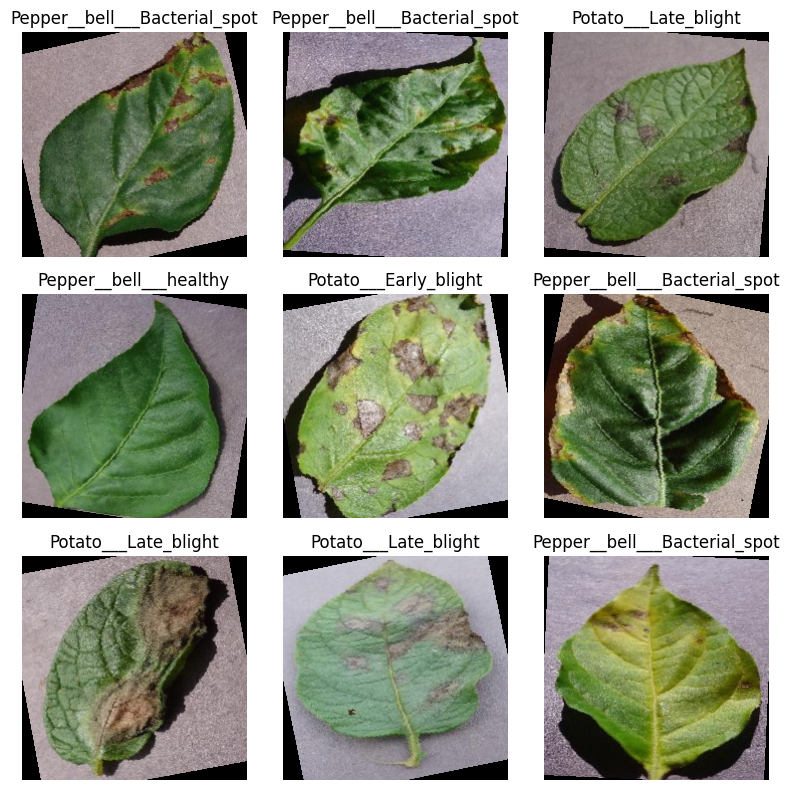

In [9]:
# Visualization of one batch of Images
classes = train_dataset.classes

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy()
    img = img * np.array(imagenet_std) + np.array(imagenet_mean)
    img = np.clip(img, 0, 1)

    label = labels[i].item()
    ax.imshow(img)
    ax.set_title(classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# INTIALIZATION OF RESNET-50 MODEL
# we adapt the model to predict our 5 classes
num_classes = len(train_dataset.classes)

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s]

Linear(in_features=2048, out_features=5, bias=True)


In [11]:
# intialization of our Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [12]:
# ====================================================
# CNN MODEL: TRAIN and Validata over multiple epochs
# ====================================================
best_val_acc = 0.0
num_epochs = 5

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # TRAIN
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # VALIDATION
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, preds = torch.max(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = running_val_loss / len(val_loader)
    val_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_acc": best_val_acc,
            "class_names": train_dataset.classes
        }, os.path.join(checkpoint_dir, "resnet50_best_checkpoint.pth"))
        print("New best model saved.")


Epoch 1/5
Train Loss: 0.3240, Train Acc: 0.9122
Val Loss: 0.0157, Val Acc: 1.0000
New best model saved.

Epoch 2/5
Train Loss: 0.0368, Train Acc: 0.9900
Val Loss: 0.0109, Val Acc: 0.9978

Epoch 3/5
Train Loss: 0.0282, Train Acc: 0.9941
Val Loss: 0.0072, Val Acc: 0.9978

Epoch 4/5
Train Loss: 0.0166, Train Acc: 0.9959
Val Loss: 0.0054, Val Acc: 0.9978

Epoch 5/5
Train Loss: 0.0094, Train Acc: 0.9973
Val Loss: 0.0036, Val Acc: 0.9978


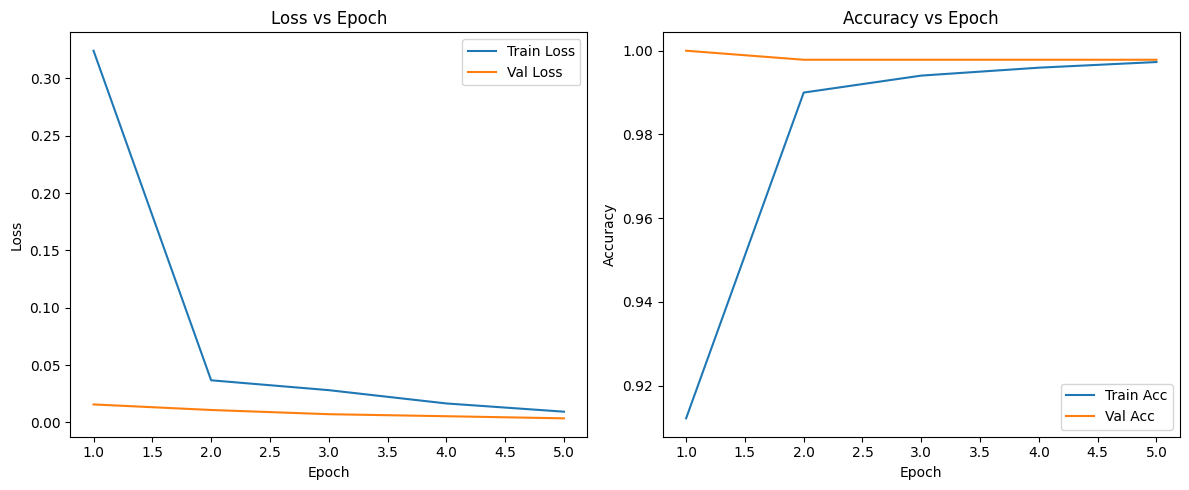

In [13]:
# Training Curve Plots
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train Acc")
plt.plot(epochs, val_accuracies, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
# LOAD BEST CHECKPOINT of model
checkpoint = torch.load(
    os.path.join(checkpoint_dir, "resnet50_best_checkpoint.pth"),
    map_location=device
)

best_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
best_model.fc = nn.Linear(best_model.fc.in_features, num_classes)
best_model.load_state_dict(checkpoint["model_state_dict"])
best_model = best_model.to(device)
best_model.eval()

print("Loaded best model from epoch:", checkpoint["epoch"])
print("Best validation accuracy:", checkpoint["best_val_acc"])

Loaded best model from epoch: 1
Best validation accuracy: 1.0


In [15]:
# TEST evaluation
test_loss = 0.0
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = best_model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, preds = torch.max(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss /= len(test_loader)
test_acc = correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.0171
Test Accuracy: 0.9978


In [16]:
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes, digits=4))

                               precision    recall  f1-score   support

Pepper__bell___Bacterial_spot     1.0000    1.0000    1.0000       100
       Pepper__bell___healthy     1.0000    1.0000    1.0000       148
        Potato___Early_blight     1.0000    0.9900    0.9950       100
         Potato___Late_blight     0.9901    1.0000    0.9950       100
             Potato___healthy     1.0000    1.0000    1.0000        16

                     accuracy                         0.9978       464
                    macro avg     0.9980    0.9980    0.9980       464
                 weighted avg     0.9979    0.9978    0.9978       464



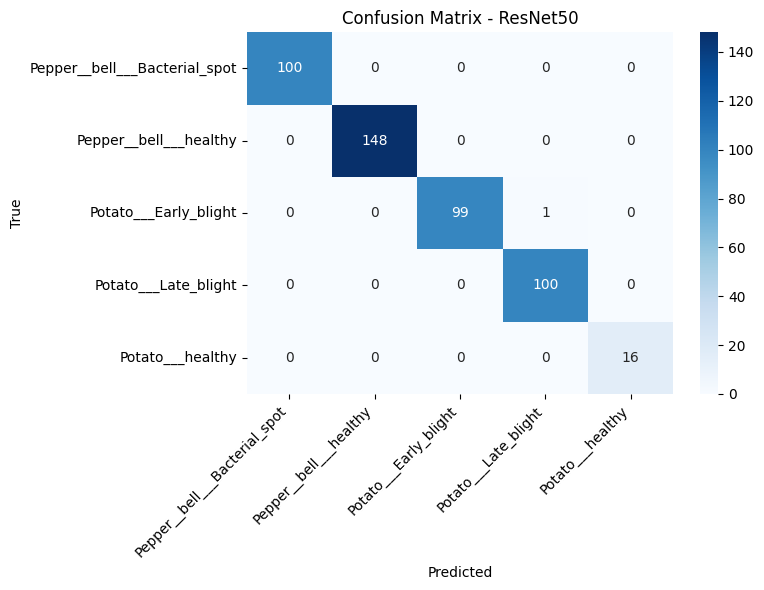

In [17]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - ResNet50")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()